In [ ]:
import math
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import DataLoader, Dataset, Subset
import yfinance as yf


In [ ]:
apple_data = pd.read_excel("/kaggle/input/datasets/qizhaochan/news-info-part2/News_Info_part2.xlsx", sheet_name="Pepsi")
apple_data['date']=pd.to_datetime(apple_data['date']).dt.date

apple_data.dropna(inplace=True)
apple_data

,date,title,content,link,symbols,tags,sentiment
0,2024-05-08,Steady Dividend Plays: 3 Stocks Promising Reli...,The stock market has performed well so far thi...,https://finance.yahoo.com/news/steady-dividend...,"['JNJ.US', 'PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.H...",[],"{'polarity': 0.998, 'neg': 0.014, 'neu': 0.869..."
1,2024-05-08,"7-Eleven, Inc. to Release New Limited Edition ...","7-Eleven®, Speedway® and Stripes® customers ca...",https://finance.yahoo.com/news/7-eleven-inc-re...,"['PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.HM', 'PEP.M...",[],"{'polarity': 0.995, 'neg': 0.012, 'neu': 0.885..."
2,2024-05-08,UPS CFO Brian Newman is departing. But the fir...,Good morning. A delivery giant is searching fo...,https://finance.yahoo.com/news/ups-cfo-brian-n...,"['HD.MX', 'HD.NEO', 'HD.US', 'HDI.BE', 'HDI.DU...",[],"{'polarity': 0.998, 'neg': 0.015, 'neu': 0.874..."
3,2024-05-08,VDC: Strong and Steady Consumer Staples ETF,"Whether it’s Coca-Cola (NYSE:KO), Hershey (NYS...",https://finance.yahoo.com/news/vdc-strong-stea...,"['0J4X.LSE', '0P59.LSE', '4I1.BE', '4I1.F', '4...",[],"{'polarity': 0.999, 'neg': 0.032, 'neu': 0.817..."
4,2024-05-08,Steady Dividend Plays: 3 Stocks Promising Reli...,"Johnson &amp; Johnson, PepsiCo, and Southern C...",https://investorplace.com/2024/05/three-stocks...,"['JNJ.US', 'PEP.US']",[],"{'polarity': 0.671, 'neg': 0, 'neu': 0.766, 'p..."
...,...,...,...,...,...,...,...
3642,2018-02-05,Research Report Identifies Franklin Electric C...,"NEW YORK, Feb. 05, 2018 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"['BDX.US', 'FELE.US', 'FHN.US', 'OTTR.US', 'PE...",['FUNDAMENTAL MARKETS'],"{'polarity': 0.997, 'neg': 0.008, 'neu': 0.934..."
3643,2018-02-01,"PepsiCo, Inc. (Nasdaq: PEP) to Ring The Nasdaq...","ADVISORY, Feb. 01, 2018 (GLOBE NEWSWIRE) --\...",https://www.globenewswire.com/news-release/201...,"['NDAQ.US', 'PEP.US']","['ADVISORY', 'INC', 'NASDAQ', 'NASDAQ:NDAQ']","{'polarity': 0.996, 'neg': 0.004, 'neu': 0.866..."
3644,2017-11-29,Investor Expectations to Drive Momentum within...,"NEW YORK, Nov. 29, 2017 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"['DAL.US', 'HUM.US', 'NUAN.US', 'PEP.US', 'SYY...",['FUNDAMENTAL MARKETS'],"{'polarity': 0.995, 'neg': 0.009, 'neu': 0.936..."
3645,2017-10-24,Consolidated Research: 2018 Summary Expectatio...,"NEW YORK, Oct. 24, 2017 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"['GRPN.US', 'M.US', 'PEP.US', 'RDC.US', 'SLB.U...",['FUNDAMENTAL MARKETS'],"{'polarity': 0.996, 'neg': 0.012, 'neu': 0.926..."


In [ ]:
unique_tickers = pd.read_excel("/kaggle/input/datasets/qizhaochan/fixed-node/fixed nodes.xlsx")['Pepsi'].dropna()
unique_tickers = list(unique_tickers)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

def finbert_sentiment_pipeline(device=-1):
    model_name = "ProsusAI/finbert"

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)

    return pipeline(
        "sentiment-analysis",
        model=model,
        tokenizer=tokenizer,
        device=device
    )

In [ ]:



def classify_news_sentiment(news_df: pd.DataFrame, pipe) -> pd.DataFrame:
    """
    Run FinBERT sentiment on each news text and return the news_df with 'label' and 'score' columns.
    label usually one of: 'positive', 'neutral', 'negative' (model dependent); we will normalize later.
    """
    texts = news_df["title"].tolist()
    # pipe can process batches; to be safe, process in small batches
    batch_size = 16
    labels = []
    scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        outs = pipe(batch, truncation=True)
        # outs: list of {'label': 'positive', 'score': 0.98} etc.
        for o in outs:
            labels.append(o["label"])
            scores.append(float(o.get("score", 0.0)))
    import copy
    df = news_df.copy().reset_index(drop=True)
    df["label"] = labels
    df["score"] = scores
    return df

In [ ]:
from typing import List, Tuple

def aggregate_sentiment_per_company_day(news_df_with_labels: pd.DataFrame, tickers: List[str], date_index: pd.DatetimeIndex):
    """
    For each (date, ticker) compute an aggregated sentiment score.
    Strategy:
      - Map labels to numeric: positive -> +1, neutral -> 0, negative -> -1
      - Use label * score as weighted value, average across news mentioning the ticker (normalized format) on that date.
    Returns:
      sentiment_df: DataFrame indexed by date_index (dates from price_df) with columns tickers (shape T x N)
    """

    def label_to_num(lab):
        if pd.isna(lab):
            return 0.0
        s = str(lab).lower()
        if "pos" in s:
            return 1.0
        elif "neg" in s:
            return -1.0
        else:
            return 0.0

    tmp = news_df_with_labels.copy()
    #tmp["date"] = pd.to_datetime(tmp["date"]).dt.normalize()

    # Ensure mentions are parsed lists
    if isinstance(tmp["mentions"].iloc[0], str):
        tmp["mentions"] = tmp["mentions"].apply(lambda x: eval(x) if isinstance(x, str) else x)

    # Normalize tickers in 'mentions' — e.g. "AAPL.US" -> "AAPL"
    def normalize_ticker(name):
        if not isinstance(name, str):
            return name
        return name.split(".")[0].upper().strip()

    tmp["mentions"] = tmp["mentions"].apply(lambda lst: [normalize_ticker(x) for x in lst])

    # Aggregate sentiment values
    accum = {}
    for _, row in tmp.iterrows():
        d = row["date"]
        numeric = label_to_num(row["label"]) * float(row["score"])
        for t in row["mentions"]:
            if t in tickers:  # only keep known companies
                accum.setdefault((d, t), []).append(numeric)

    # Build sentiment matrix
    rows = []
    for d in date_index:
        row_vals = []
        for t in tickers:
            vals = accum.get((d, t), [])
            row_vals.append(float(np.mean(vals)) if vals else 0.0)
        rows.append(row_vals)

    sentiment_df = pd.DataFrame(rows, index=date_index, columns=tickers).astype(np.float32)
    return sentiment_df


In [ ]:
start_date = apple_data["date"].min()
end_date = apple_data["date"].max()

In [ ]:
price_df = yf.download(unique_tickers, start=start_date, end=end_date, progress=False)["Close"]

#price_df = price_df[unique_tickers]
price_df = price_df.dropna(how="all").ffill().dropna(axis=1)  # drop tickers with no data
print(f"Price data shape: {price_df.shape}")

news_df = apple_data[['date', 'title', 'symbols']]  # Include symbols for mentions
news_df.rename(columns={'symbols': 'mentions'}, inplace=True)

# run FinBERT sentiment classification (this will download model the first time)
print("Loading FinBERT pipeline (this may take a while for first run)...")
pipe = finbert_sentiment_pipeline()  # cpu; set device=0 for GPU
print("Classifying synthetic news with FinBERT...")
news_labeled = classify_news_sentiment(news_df, pipe)
news_labeled.reset_index(inplace=True, drop=True)  # Reset index to make date a column again
print("Sample labeled news:")
print(news_labeled.head())

/tmp/ipykernel_58/3160259362.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(unique_tickers, start=start_date, end=end_date, progress=False)["Close"]


Price data shape: (2145, 1694)
Loading FinBERT pipeline (this may take a while for first run)...


/tmp/ipykernel_58/3160259362.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_df.rename(columns={'symbols': 'mentions'}, inplace=True)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   
1  2024-05-08  7-Eleven, Inc. to Release New Limited Edition ...   
2  2024-05-08  UPS CFO Brian Newman is departing. But the fir...   
3  2024-05-08        VDC: Strong and Steady Consumer Staples ETF   
4  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   

                                            mentions     label     score  
0  ['JNJ.US', 'PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.H...  positive  0.929564  
1  ['PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.HM', 'PEP.M...   neutral  0.894171  
2  ['HD.MX', 'HD.NEO', 'HD.US', 'HDI.BE', 'HDI.DU...   neutral  0.568551  
3  ['0J4X.LSE', '0P59.LSE', '4I1.BE', '4I1.F', '4...  positive  0.932543  
4                               ['JNJ.US', 'PEP.US']  positive  0.929564  


In [ ]:
# Get all columns
cols = price_df.columns.tolist()

# Remove 'PEP' from list and insert at beginning
cols.remove('PEP')
cols = ['PEP'] + cols

# Reorder DataFrame
price_df = price_df.reindex(columns=cols)
price_df

Ticker,PEP,A,AA,AAL,AAON,AAP,AAPL,AB,ABBV,ABEV,...,YELP,YORW,YUM,YYY,ZBH,ZBRA,ZG,ZION,ZTS,ZUMZ
Date,,,,,,,,,,,,,,,,,,,,,
2015-10-28,74.027512,34.403061,20.216232,43.731598,13.238202,168.531540,26.727400,10.533683,34.329144,3.311999,...,22.070000,19.019558,43.115547,6.129736,86.944061,78.639999,31.139999,21.941797,39.376141,17.219999
2015-10-29,74.070755,34.568096,20.126278,43.731598,13.001699,171.307419,27.009758,10.377362,34.870579,3.298453,...,22.950001,18.506607,42.843750,6.103765,93.162575,77.839996,30.520000,22.016489,39.566936,17.389999
2015-10-30,73.631226,34.623116,20.081308,44.074890,12.740294,172.131577,26.778944,10.317242,38.383423,3.298453,...,22.250000,18.578737,41.898361,6.142725,92.896080,76.900002,30.809999,21.486246,39.076321,17.480000
2015-11-02,73.062004,35.384155,20.621004,44.313290,13.499609,173.823105,27.155420,10.269140,40.852074,3.352637,...,23.799999,18.618814,42.441963,6.175192,95.010399,78.620003,30.870001,21.807373,40.193817,17.870001
2015-11-03,72.716164,35.090763,21.093239,44.437519,14.140666,172.365738,27.466902,10.233066,40.239746,3.501643,...,24.120001,18.346306,42.666496,6.181686,94.521797,78.620003,30.990000,21.635609,42.444874,18.389999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-01,161.286102,136.282669,33.435448,13.580000,93.612328,69.596146,167.618698,27.178986,150.059494,2.147524,...,40.439999,33.987976,129.586472,8.960877,116.971992,309.049988,41.439999,38.855957,153.279419,17.120001
2024-05-02,161.562347,135.132965,35.085258,13.860000,90.064827,71.397270,171.311691,27.318529,149.215118,2.211766,...,40.000000,34.599945,129.337494,8.991514,115.895813,312.709991,39.189999,39.682678,161.721878,17.120001
2024-05-03,162.206970,137.029495,35.895515,13.850000,77.688217,72.721909,181.558868,27.830496,151.980240,2.230121,...,39.990002,34.741173,128.638489,9.083418,119.026550,309.589996,40.070000,40.518688,161.567169,17.180000


In [ ]:
sentiment_df = aggregate_sentiment_per_company_day(news_labeled, list(price_df.columns), date_index = price_df.index.date)
sentiment_df.head(10)

,PEP,A,AA,AAL,AAON,AAP,AAPL,AB,ABBV,ABEV,...,YELP,YORW,YUM,YYY,ZBH,ZBRA,ZG,ZION,ZTS,ZUMZ
2015-10-28,0.844525,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-10-29,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-10-30,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-11-02,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-11-03,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-11-04,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-11-05,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-11-06,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-11-09,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-11-10,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
sentiment_df.describe()

,PEP,AA,AAL,AAPL,ABBV,ABEV,ABR,ABT,ACGL,ACN,...,WFC,WHR,WM,WMT,WTER,WYNN,XEL,XLP,XOM,YUM
count,2145.000000,2145.000000,2145.000000,2145.000000,2145.000000,2145.000000,2145.000000,2145.000000,2145.000000,2145.000000,...,2145.000000,2145.000000,2145.000000,2145.000000,2145.000000,2145.000000,2145.000000,2145.000000,2145.000000,2145.000000
mean,0.033933,0.000673,0.000390,-0.002280,0.002909,-0.000161,-0.000239,-0.000286,0.000379,0.000007,...,-0.000446,-0.000431,0.000382,0.001303,0.000412,-0.000438,0.000211,0.001159,0.000415,0.000528
std,0.188070,0.022175,0.031590,0.079064,0.045646,0.034601,0.011061,0.010767,0.017547,0.014904,...,0.034965,0.019976,0.017696,0.069841,0.019080,0.020291,0.009762,0.042642,0.026213,0.047930
min,-0.969027,0.000000,-0.939783,-0.972278,-0.167652,-0.967064,-0.512303,-0.480355,0.000000,-0.480355,...,-0.946531,-0.925184,0.000000,-0.936992,0.000000,-0.939783,0.000000,-0.940351,-0.599539,-0.837776
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.954954,0.806101,0.887282,0.892257,0.874850,0.743845,0.000000,0.000000,0.812670,0.495488,...,0.924030,0.000000,0.819595,0.934707,0.883666,0.000000,0.452097,0.942725,0.787756,0.934558


In [ ]:
import matplotlib.pyplot as plt


def plot_predictions(predictions):

    plt.figure(figsize=(14, 6))

    # True values
    true_values = predictions[
        list(predictions.keys())[0]
    ]["true"]

    plt.plot(
        true_values,
        label="True",
        linewidth=2
    )

    # Model predictions
    for name, data in predictions.items():

        plt.plot(
            data["pred"],
            label=name,
            alpha=0.8
        )

    plt.xlabel("Test Samples")
    plt.ylabel("Normalized Close Price")
    plt.title(
        "Predicted vs True Stock Price "
        "(Target Company)"
    )

    plt.legend()
    plt.grid(True)
    plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
/tmp/ipykernel_58/3895887188.py:115: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)



Training LSTM...
Starting training with early stopping (patience=20)...
  New best model! Val Loss: 1.296760
Epoch 05/100 | Train Loss: 0.156655 | Val Loss: 1.836314 | Patience: 3/20
Epoch 10/100 | Train Loss: 0.114461 | Val Loss: 1.844529 | Patience: 8/20
Epoch 15/100 | Train Loss: 0.095567 | Val Loss: 2.232378 | Patience: 13/20
Epoch 20/100 | Train Loss: 0.077757 | Val Loss: 2.437309 | Patience: 18/20
Early stopping triggered at epoch 21
Best validation loss: 1.296760
Loading best model for testing...
LSTM Test Results (Target Company Index 0): {'MSE': 2.315122365951538, 'MAE': 1.211548924446106}

Training GRU...
Starting training with early stopping (patience=20)...
  New best model! Val Loss: 2.939076
Epoch 05/100 | Train Loss: 0.125871 | Val Loss: 3.185124 | Patience: 3/20
Epoch 10/100 | Train Loss: 0.092962 | Val Loss: 3.277495 | Patience: 8/20
  New best model! Val Loss: 2.867191
  New best model! Val Loss: 2.799662
  New best model! Val Loss: 2.539472
Epoch 15/100 | Train Loss

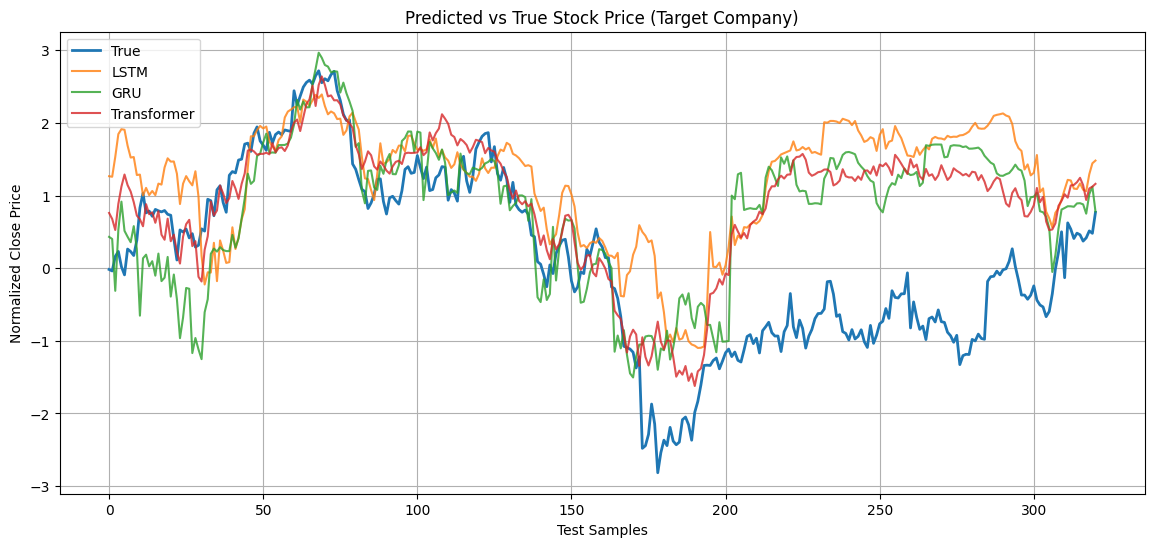


--- Final Comparison ---
LSTM       : MSE 2.315122, MAE 1.211549
GRU        : MSE 1.646364, MAE 0.988047
Transformer: MSE 1.392825, MAE 0.887285


In [ ]:


# =======================================
# 1. Models: LSTM, GRU, and Transformer
# =======================================
''''''
class RNNModel(nn.Module):
    """
    Recurrent Neural Network model (LSTM or GRU) for multi-company target prediction.

    Inputs:
        seq_feats: Tensor of shape (batch, seq_len, N, 3)
    Output:
        out: Tensor of shape (batch,) representing next-day normalized close price
             for target_idx = 0.
    """
    def __init__(
        self,
        in_feats: int,
        hidden_dim: int = 32,
        out_dim: int = 1,
        num_layers: int = 1,
        dropout: float = 0.2,
        model_type: str = "LSTM"
    ):
        super().__init__()
        # in_feats = N * 3
        if model_type == "LSTM":
            self.rnn = nn.LSTM(
                input_size=in_feats,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout
            )
        else:
            self.rnn = nn.GRU(
                input_size=in_feats,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0
            )
        self.fc = nn.Linear(hidden_dim, out_dim)

    def forward(self, seq_feats: torch.Tensor) -> torch.Tensor:
        # seq_feats: (batch, seq_len, N, 3)
        batch, seq_len, N, F = seq_feats.shape

        # Flatten spatial/ticker feature dimensions at each time step:
        # (batch, seq_len, N, 3) -> (batch, seq_len, N * 3)
        x = seq_feats.view(batch, seq_len, N * F)

        # Recurrent pass:
        # out: (batch, seq_len, hidden_dim)
        out, _ = self.rnn(x)

        # Take the last time step hidden state:
        # out[:, -1, :]: (batch, hidden_dim)
        last_hidden = out[:, -1, :]

        # Linear projection to single target output:
        # pred: (batch, 1) -> squeezed to (batch,)
        pred = self.fc(last_hidden).squeeze(-1)

        return pred


class PositionalEncoding(nn.Module):
    """
    Standard Sinusoidal Positional Encoding for Transformer inputs.
    """
    def __init__(self, d_model: int, max_len: int = 500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # Shape: (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1)]


class TransformerModel(nn.Module):
    def __init__(
        self,
        in_feats: int,
        hidden_dim: int = 64,
        out_dim: int = 1,
        nhead: int = 1,  #4
        num_layers: int = 1,   #2
        dropout: float = 0.2
    ):
        super().__init__()

        # Add input normalization for stability
        self.input_norm = nn.LayerNorm(in_feats)

        self.encoder = nn.Linear(in_feats, hidden_dim)
        self.pos_encoder = PositionalEncoding(hidden_dim)

        # Add layer normalization after encoder
        self.encoder_norm = nn.LayerNorm(hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=hidden_dim * 2,
            dropout=dropout,
            batch_first=True,
            activation='gelu'  # GELU is more stable than ReLU
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Add output normalization
        self.output_norm = nn.LayerNorm(hidden_dim)
        self.fc = nn.Linear(hidden_dim, out_dim)

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, seq_feats: torch.Tensor) -> torch.Tensor:
        batch, seq_len, N, F = seq_feats.shape

        # Check for NaN in input
        if torch.isnan(seq_feats).any():
            print("WARNING: NaN in Transformer input!")
            seq_feats = torch.nan_to_num(seq_feats, nan=0.0)

        # Flatten spatial dimensions
        x = seq_feats.view(batch, seq_len, N * F)

        # Input normalization (critical for Transformer)
        x = self.input_norm(x)

        # Clip extreme values
        x = torch.clamp(x, -10, 10)

        # Linear projection
        x = self.encoder(x)
        x = self.encoder_norm(x)

        # Add positional encoding
        x = self.pos_encoder(x)

        # Transformer encoder
        x = self.transformer(x)

        # Output normalization
        x = self.output_norm(x)

        # Take last time step
        last_hidden = x[:, -1, :]

        # Final projection
        pred = self.fc(last_hidden).squeeze(-1)

        # Check for NaN in output
        if torch.isnan(pred).any():
            print("WARNING: NaN in Transformer output!")
            pred = torch.nan_to_num(pred, nan=0.0)

        return pred


class FinancialDataset(Dataset):
    """
    Financial Dataset yielding temporal sequences of all companies' features
    and targeting ONLY the next-day normalized close price of target_idx.

    Features:
        1. Rolling normalized close price
        2. News sentiment score
        3. Historical annualized volatility
    """

    def __init__(
        self,
        price_df,
        sentiment_df,
        seq_len=5,
        window_size=252,
        vol_window=20,
        target_idx=0
    ):
        super().__init__()

        self.seq_len = seq_len
        self.target_idx = target_idx
        self.tickers = list(price_df.columns)




        # Convert to numpy
        prices = price_df.values.astype(np.float32)
        sentiments = sentiment_df.values.astype(np.float32)

        T, N = prices.shape


        # =============================
        # 1. Compute log returns
        # =============================
        log_returns = np.zeros((T, N), dtype=np.float32)

        ratio = np.divide(
            prices[1:],
            prices[:-1],
            out=np.ones_like(prices[1:]),
            where=(prices[:-1] > 0)
        )

        ratio = np.maximum(ratio, 1e-8)

        log_returns[1:] = np.log(ratio)



        # =============================
        # 2. Feature calculation
        # =============================

        norm_prices = np.zeros((T, N), dtype=np.float32)

        annualized_vol = np.zeros(
            (T, N),
            dtype=np.float32
        )


        for t in range(T):

            # ----------------------------------
            # Rolling price normalization
            #
            # IMPORTANT:
            # Only use prices BEFORE current day
            # to avoid look-ahead bias.
            #
            # Feature at t:
            # statistics from t-window_size ... t-1
            # ----------------------------------

            if t == 0:

                norm_prices[t] = 0.0

            else:

                start_idx = max(0, t - window_size)

                historical_prices = prices[start_idx:t]


                mean_t = historical_prices.mean(axis=0)

                # Change this inside FinancialDataset:
                std_t = historical_prices.std(axis=0)
                # Replace 0 or near-zero standard deviations with 1.0 to prevent division by zero / NaNs
                std_t = np.where(std_t < 1e-6, 1.0, std_t)


                norm_prices[t] = (
                    prices[t] - mean_t
                ) / std_t



            # ----------------------------------
            # Historical volatility
            #
            # Only use returns before current day
            #
            # volatility at t:
            # returns[t-vol_window:t]
            # ----------------------------------

            if t < vol_window:

                annualized_vol[t] = 0.0

            else:

                return_window = log_returns[
                    t - vol_window:t
                ]


                daily_vol = (
                    return_window.std(axis=0)
                )


                annualized_vol[t] = (
                    daily_vol * np.sqrt(252)
                )



        # =============================
        # 3. Build feature tensor
        # =============================

        feature_list = []

        for t in range(T - 1):

            feat_t = np.stack(
                [
                    norm_prices[t],
                    sentiments[t],
                    annualized_vol[t]
                ],
                axis=1
            )

            feature_list.append(feat_t)



        # Shape:

        self.features = np.stack(
            feature_list,
            axis=0
        )



        # =============================
        # 4. Build prediction target
        # =============================
        #
        # Input:
        # day t-seq_len+1 ... day t
        #
        # Target:
        # day t+1 normalized price
        #
        # =============================

        self.targets = norm_prices[1:T]



        # =============================
        # 5. Valid sliding windows
        # =============================

        self.valid_indices = list(
            range(
                seq_len - 1,
                len(self.features)
            )
        )



    def __len__(self):

        return len(self.valid_indices)



    def __getitem__(self, idx):

        end_t = self.valid_indices[idx]

        start_t = (
            end_t - self.seq_len + 1
        )


        # Shape:
        # (seq_len, N, 3)

        seq_feats = torch.tensor(
            self.features[
                start_t:end_t + 1
            ],
            dtype=torch.float32
        )


        # Next-day normalized close price
        # target company only

        target = torch.tensor(
            self.targets[
                end_t,
                self.target_idx
            ],
            dtype=torch.float32
        )


        return {
            "seq_feats": seq_feats,
            "target": target
        }


def collate_fn(batch: list) -> Dict[str, torch.Tensor]:
    """
    Custom collate function to form batches.
    seq_feats shape: (batch, seq_len, N, 3)
    target shape: (batch,)
    """
    return {
        "seq_feats": torch.stack([item["seq_feats"] for item in batch]),
        "target": torch.stack([item["target"] for item in batch])
    }


# =======================================
# 3. Training & Evaluation Logic
# =======================================

def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    device: torch.device
) -> float:
    model.train()
    total_loss = 0.0

    for batch in loader:
        # x shape: (batch, seq_len, N, 3)
        # y shape: (batch,)
        x = batch["seq_feats"].to(device)
        y = batch["target"].to(device)

        optimizer.zero_grad()

        # pred shape: (batch,)
        pred = model(x)

        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(
    model,
    loader,
    criterion,
    device
):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for batch in loader:

            x = batch["seq_feats"].to(device)
            y = batch["target"].to(device)

            pred = model(x)

            loss = criterion(pred, y)
            total_loss += loss.item()

            all_preds.append(pred.cpu().numpy())
            all_trues.append(y.cpu().numpy())

    preds_flat = np.concatenate(all_preds, axis=0)
    trues_flat = np.concatenate(all_trues, axis=0)

    # Remove NaN if necessary
    mask = ~(np.isnan(preds_flat) | np.isnan(trues_flat))
    preds_flat = preds_flat[mask]
    trues_flat = trues_flat[mask]

    metrics = {
        "MSE": float(mean_squared_error(trues_flat, preds_flat)),
        "MAE": float(mean_absolute_error(trues_flat, preds_flat))
    }

    return (
        total_loss / len(loader),
        metrics,
        preds_flat,
        trues_flat
    )


# =======================================
# 4. Main Execution Block
# =======================================

def run_experiment(sentiment_df: pd.DataFrame, price_df: pd.DataFrame = None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tickers = sentiment_df.columns.tolist()
    target_idx = 0

    price_df['date'] = price_df.index
    sentiment_df['date'] = sentiment_df.index
    price_df['date'] = pd.to_datetime(price_df['date']).dt.tz_localize(None)
    sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.tz_localize(None)

    sentiment_df = sentiment_df.add_suffix('_sent')
    sentiment_df.rename(columns={'date_sent': 'date'}, inplace=True)

    # Merge date alignments
    merged = pd.merge(price_df, sentiment_df, on="date", how="inner")
    merged = merged.ffill().bfill()

    sentiment_df.drop(columns=['date'], inplace=True)
    price_df.drop(columns=['date'], inplace=True)

    # Instantiate dataset targeting target_idx = 0
    dataset = FinancialDataset(
        price_df=price_df,
        sentiment_df=sentiment_df,
        seq_len=5,
        target_idx=target_idx
    )

    # Sequential split (70% Train, 15% Val, 15% Test)
    n = len(dataset)
    train_end, val_end = int(n * 0.7), int(n * 0.85)

    train_loader = DataLoader(
        Subset(dataset, range(0, train_end)),
        batch_size=32,
        shuffle=True,
        collate_fn=collate_fn
    )
    val_loader = DataLoader(
        Subset(dataset, range(train_end, val_end)),
        batch_size=32,
        shuffle=False,
        collate_fn=collate_fn
    )
    test_loader = DataLoader(
        Subset(dataset, range(val_end, n)),
        batch_size=32,
        shuffle=False,
        collate_fn=collate_fn
    )

    # Calculate flattened feature input size: N * 3
    num_companies = dataset.features.shape[1]
    num_features_per_company = dataset.features.shape[2]
    input_dim = num_companies * num_features_per_company

    models = {
        "LSTM": RNNModel(in_feats=input_dim, model_type="LSTM"),
        "GRU": RNNModel(in_feats=input_dim, model_type="GRU"),
        "Transformer": TransformerModel(in_feats=input_dim)
    }

    results = {}
    predictions = {}

    for name, model in models.items():
        print(f"\nTraining {name}...")
        model.to(device)

        # Different learning rates for different models
        if name == "Transformer":
            optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Lower LR for Transformer
        else:
            optimizer = optim.Adam(model.parameters(), lr=0.001)

        criterion = nn.MSELoss()

        # ==========================================
        # EARLY STOPPING SETUP
        # ==========================================
        best_val_loss = float('inf')
        best_model_state = None
        patience_counter = 0
        patience = 20  # Number of epochs to wait before stopping
        max_epochs = 100  # Maximum number of epochs

        print(f"Starting training with early stopping (patience={patience})...")

        for epoch in range(1, max_epochs + 1):
            # Training
            train_loss = train_epoch(
                model,
                train_loader,
                optimizer,
                criterion,
                device
            )

            # Validation
            val_loss, _, _, _ = evaluate(
                model,
                val_loader,
                criterion,
                device
            )

            # Print progress every 5 epochs
            if epoch % 5 == 0:
                print(
                    f"Epoch {epoch:02d}/{max_epochs} | "
                    f"Train Loss: {train_loss:.6f} | "
                    f"Val Loss: {val_loss:.6f} | "
                    f"Patience: {patience_counter}/{patience}"
                )

            # ==========================================
            # EARLY STOPPING CHECK
            # ==========================================
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                # Save the best model state
                best_model_state = model.state_dict().copy()
                print(f"  New best model! Val Loss: {best_val_loss:.6f}")
            else:
                patience_counter += 1

            # Stop training if patience is exceeded
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch}")
                print(f"Best validation loss: {best_val_loss:.6f}")
                break

        # ==========================================
        # LOAD BEST MODEL FOR TESTING
        # ==========================================
        if best_model_state is not None:
            print("Loading best model for testing...")
            model.load_state_dict(best_model_state)
        else:
            print("Warning: No best model found, using final model.")

        # Test the best model
        _, metrics, preds, trues = evaluate(
            model,
            test_loader,
            criterion,
            device
        )

        results[name] = metrics
        predictions[name] = {
            "pred": preds,
            "true": trues
        }

        print(
            f"{name} Test Results "
            f"(Target Company Index {target_idx}): {metrics}"
        )

    # Plot after all models are done
    plot_predictions(predictions)

    print("\n--- Final Comparison ---")
    for name, m in results.items():
        print(f"{name:11s}: MSE {m['MSE']:.6f}, MAE {m['MAE']:.6f}")

    return results, predictions



if __name__ == "__main__":
    # Dummy mock sentiment dataframe setup for execution demonstration
    tickers = sentiment_df.columns.tolist()
    dates = pd.date_range(start=apple_data['date'].min(), end=apple_data['date'].max())


    run_experiment(sentiment_df, price_df)

In [ ]:
def run_experiment_simple_multiple_runs(
    sentiment_df: pd.DataFrame,
    price_df: pd.DataFrame = None,
    n_runs: int = 5
) -> Dict:


    all_results = {}

    for run in range(n_runs):
        print(f"\n--- Run {run+1}/{n_runs} ---")

        # Run your existing experiment function
        results, predictions = run_experiment(sentiment_df, price_df)

        # Store results
        for name, metrics in results.items():
            if name not in all_results:
                all_results[name] = {"MSE": [], "MAE": []}
            all_results[name]["MSE"].append(metrics["MSE"])
            all_results[name]["MAE"].append(metrics["MAE"])

    # Compute statistics
    summary = {}
    for name in all_results:
        mse_values = np.array(all_results[name]["MSE"])
        mae_values = np.array(all_results[name]["MAE"])

        summary[name] = {
            "MSE_mean": np.mean(mse_values),
            "MSE_std": np.std(mse_values),
            "MAE_mean": np.mean(mae_values),
            "MAE_std": np.std(mae_values)
        }

        print(f"\n{name}:")
        print(f"  MSE: {summary[name]['MSE_mean']:.6f} ± {summary[name]['MSE_std']:.6f}")
        print(f"  MAE: {summary[name]['MAE_mean']:.6f} ± {summary[name]['MAE_std']:.6f}")

    return summary

# Usage
summary = run_experiment_simple_multiple_runs(sentiment_df, price_df, n_runs=5)
summary


--- Run 1/5 ---


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
/tmp/ipykernel_58/3895887188.py:115: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)



Training LSTM...
Starting training with early stopping (patience=20)...
  New best model! Val Loss: 1.522810
Epoch 05/100 | Train Loss: 0.139210 | Val Loss: 1.607483 | Patience: 3/20
Epoch 10/100 | Train Loss: 0.100527 | Val Loss: 1.371057 | Patience: 8/20
  New best model! Val Loss: 1.371057
